# Machine Learning Backtesting Pipeline (TensorFlow & MLflow)
This notebook implements an Expanding Window Time-Series Split, Random Forest (with GridSearchCV), Deep Neural Network (TensorFlow/Keras + KerasTuner), and Decile Sorting Backtesting.
All model training and hyperparameter searches are tracked using MLflow.


In [1]:
import IPython.core.pylabtools
import IPython.core.pylabtools
import os
import sys
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import mlflow
import keras_tuner as kt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from scipy.stats import spearmanr

# Ask TensorFlow to list all available physical GPUs
gpu_devices = tf.config.list_physical_devices('GPU')

if gpu_devices:
    print(f"✅ M3 Pro GPU ACTIVATED! Found: {gpu_devices}")
    # Optional: Set memory growth to prevent TF from hoarding all unified memory
    tf.config.experimental.set_memory_growth(gpu_devices[0], True)
else:
    print("❌ GPU not found. TensorFlow is falling back to the CPU.")

✅ M3 Pro GPU ACTIVATED! Found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Setup & Data Loading (with MLflow)

In [2]:
# Fix random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Spark setup
from dotenv import load_dotenv
os.chdir(os.path.abspath(os.path.join(os.getcwd(), '../../')))
sys.path.append(os.getcwd())

from src.common.setup_spark import create_spark_session
from config.config_spark import Paths

# MLflow Setup
mlflow.set_tracking_uri("sqlite:///mlflow.db") # Local SQLite database for tracking
experiment_name = "SP500_Momentum_Backtest"
mlflow.set_experiment(experiment_name)
print(f"MLflow Experiment set to: {experiment_name}")

spark = create_spark_session()
print("Spark Session created.")

# Load Data
df_gold = spark.read.format("delta").load(Paths.SP500_MOMENTUM_VALUE_PROFITABLE_WEEKLY_GOLD)
df_gold.createOrReplaceTempView("gold_prices")

df = df_gold.toPandas()

df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['week'] = df['date'].dt.weekday

#df = df[df['bull_market']==1]

print(f"Data loaded: {df.shape}")
print(f"Years: {df['year'].unique().min()}")


2026-03-13 15:53:15.890 | INFO     | src.common.setup_spark:create_spark_session:19 - 🛠️ Configurant Spark avec le connecteur GCS : https://repo1.maven.org/maven2/com/google/cloud/bigdataoss/gcs-connector/hadoop3-2.2.6/gcs-connector-hadoop3-2.2.6-shaded.jar


MLflow Experiment set to: SP500_Momentum_Backtest


26/03/13 15:53:16 WARN Utils: Your hostname, MacBook-Pro-5.local resolves to a loopback address: 127.0.0.1; using 192.168.1.1 instead (on interface en0)
26/03/13 15:53:16 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Ivy Default Cache set to: /Users/forget/.ivy2/cache
The jars for the packages stored in: /Users/forget/.ivy2/jars
io.delta#delta-spark_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-a4064217-368b-4812-881f-6e68c4c492bb;1.0
	confs: [default]
	found io.delta#delta-spark_2.12;3.2.1 in central
	found io.delta#delta-storage;3.2.1 in central
	found org.antlr#antlr4-runtime;4.9.3 in central
:: resolution report :: resolve 68ms :: artifacts dl 3ms
	:: modules in use:
	io.delta#delta-spark_2.12;3.2.1 from central in [default]
	io.delta#delta-storage;3.2.1 from central in [default]
	org.antlr#antlr4-runtime;4.9.3 from central in [default]
	---------------------------------------------------------------------
	|   

:: loading settings :: url = jar:file:/opt/homebrew/Caskroom/miniforge/base/envs/ml-prod-v2/lib/python3.10/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


26/03/13 15:53:16 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/13 15:53:18 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/03/13 15:53:18 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
26/03/13 15:53:18 WARN Utils: Service 'SparkUI' could not bind on port 4042. Attempting port 4043.
26/03/13 15:53:18 WARN Utils: Service 'SparkUI' could not bind on port 4043. Attempting port 4044.
26/03/13 15:53:18 WARN Utils: Service 'SparkUI' could not bind on port 4044. Attempting port 4045.
2026-03-13 15:53:18.914 | SUCCESS  | src.common.setup_spark:create_spark_session:38 - ✅ Spark Session 'SparkApp' créée avec succès ! (Version: 3.5.3)


Spark Session created.


Data loaded: (683596, 129)
Years: 1985


In [3]:
df.describe()

,date,adjClose,volume,market_return,risk_free_rate,retvol,maxret,ill,beta,mom1w,...,daysOfInventoryOutstanding,operatingCycle,cashConversionCycle,freeCashFlowToEquity,freeCashFlowToFirm,tangibleAssetValue,netCurrentAssetValue,year,month,week
count,683596,683596.000000,6.835960e+05,683596.000000,683596.000000,683596.000000,683596.000000,683596.000000,683596.000000,683596.000000,...,6.835960e+05,6.835960e+05,6.835960e+05,6.835960e+05,6.835960e+05,6.835960e+05,6.835960e+05,683596.000000,683596.000000,683596.000000
mean,2010-09-19 10:36:10.166005248,67.957243,7.811341e+06,0.000429,0.000088,-0.004572,-0.003598,-0.002588,-0.000276,0.000098,...,1.211649e+02,2.028339e+02,1.901064e+00,-9.804045e+09,7.328922e+08,5.671369e+09,-2.641322e+10,2010.214094,6.561390,3.963651
min,1985-09-06 00:00:00,0.004101,1.000000e+01,-0.088068,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-6.767609e+04,-6.676884e+04,-6.085191e+05,-9.736720e+11,-2.851201e+13,-2.657730e+11,-3.100327e+12,1985.000000,1.000000,0.000000
25%,2003-02-21 00:00:00,12.120000,9.523140e+05,-0.004305,0.000004,-0.504065,-0.502890,-0.502538,-0.499044,-0.498998,...,0.000000e+00,5.117988e+01,3.502875e+00,-7.154000e+09,-6.622557e+06,0.000000e+00,-1.340080e+10,2003.000000,4.000000,4.000000
50%,2012-07-13 00:00:00,29.180000,2.186242e+06,0.000874,0.000063,-0.004739,-0.003690,0.000000,0.000000,0.000000,...,3.318028e+01,9.460297e+01,4.366362e+01,-2.026300e+09,1.245994e+08,1.641900e+09,-3.365100e+09,2012.000000,7.000000,4.000000
75%,2019-09-13 00:00:00,67.410000,5.093956e+06,0.005707,0.000174,0.493976,0.495702,0.497099,0.498182,0.499044,...,7.760246e+01,1.482690e+02,9.445779e+01,-1.070000e+08,5.624792e+08,6.045000e+09,-8.793100e+07,2019.000000,10.000000,4.000000
max,2026-02-20 00:00:00,9924.400000,9.276606e+09,0.092871,0.000328,1.000000,1.000000,1.000000,1.000000,1.000000,...,3.646790e+06,3.646790e+06,3.646007e+06,4.842830e+11,2.853340e+13,1.622538e+12,3.164338e+13,2026.000000,12.000000,4.000000
std,NaN,192.396685,4.653942e+07,0.010902,0.000087,0.577229,0.577935,0.577449,0.577008,0.577260,...,1.591193e+04,1.609886e+04,1.666346e+04,4.049973e+10,3.152945e+11,2.513286e+10,3.384185e+11,10.692233,3.463922,0.206899


### Calculate Target Variable: 1-Month Ahead Expected Excess Return

In [4]:
import pandas as pd
import numpy as np

def create_advanced_target(df, forward_weeks=4):
    """
    Calculates a rolling forward return on weekly data, then converts it 
    into a Cross-Sectional Z-Score to isolate 'Alpha' from 'Beta'.
    """
    df = df.copy()
    
    # 0. S'assurer des formats et du tri initial (CRITIQUE pour le shift)
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values(by=['symbol', 'date'])
    
    # 1. Calculer le rendement futur sur N semaines (ex: 4 semaines = 1 mois)
    # On divise le prix dans 4 semaines par le prix d'aujourd'hui
    df['return_forward'] = df.groupby('symbol')['adjClose'].shift(-forward_weeks) / df['adjClose'] - 1

    df['target_y'] = df['return_forward']
    
    # 5. Nettoyer le dataset final
    df = df.drop(columns=['return_forward'])
    df = df.dropna(subset=['target_y'])
    
    return df

df = create_advanced_target(df, forward_weeks=52)


## 4. Algorithm Model Architectures

In [5]:

Valorisation = ['priceToBookRatio', 'priceToSalesRatio', 'priceToEarningsRatio', 'evToEBITDA', 'freeCashFlowYield']
Profitable = ['returnOnEquity', 'returnOnInvestedCapital', 'returnOnAssets', 'grossProfitMargin', 'operatingProfitMargin', 'ebitdaMargin']
Momentum = ['market_return', 'risk_free_rate', 'retvol', 'maxret', 'ill', 'beta', 'mom1w', 'mom1m', 'mom3m', 'mom6m', 'mom12m', 'mom36m', 'mom60m', 'chmom', 'high52', 'dist_ma4', 'dist_ma12', 'dist_ma25', 'dist_ma50']
colonnes_biais = ['date', 'volume', 'adjClose','symbol', 'target_y']

features = set(Valorisation) | set(Profitable) | set(Momentum) - set(colonnes_biais)
features = list(features)
print("features :", features)

features : ['grossProfitMargin', 'mom6m', 'mom3m', 'priceToEarningsRatio', 'maxret', 'priceToSalesRatio', 'mom60m', 'freeCashFlowYield', 'dist_ma4', 'retvol', 'beta', 'returnOnInvestedCapital', 'mom12m', 'operatingProfitMargin', 'mom1w', 'mom36m', 'ill', 'high52', 'dist_ma12', 'risk_free_rate', 'mom1m', 'returnOnAssets', 'dist_ma50', 'evToEBITDA', 'returnOnEquity', 'ebitdaMargin', 'market_return', 'chmom', 'dist_ma25', 'priceToBookRatio']


In [6]:
# Define features. Exclude identifiers and target.
print(df.isna().sum())

# Ensure no NaNs in features

df = df.dropna(subset=features)
df = df.reset_index(drop=True)

print(f"Data after target creation: {df.shape}")
print(f"Years: {df['year'].unique().min()}")

symbol                  0
date                    0
adjClose                0
volume                  0
market_return           0
                       ..
netCurrentAssetValue    0
year                    0
month                   0
week                    0
target_y                0
Length: 130, dtype: int64
Data after target creation: (646208, 130)
Years: 1985


## 2. Expanding Window Time-Series Split

In [7]:

def get_classic_train_val_test_splits(df, val_years, test_years):
    """
    Yields a single, classic chronological split (Train -> Val -> Test).
    It splits based on the last N years of your dataset.
    """
    years = sorted(df['year'].unique())
    
    print(f"Total years in dataset: {years[0]} to {years[-1]}")
    
    # Calculate the cutoff years from the end of the dataset
    test_start_year = years[-test_years]
    val_start_year = years[-(test_years + val_years)]
    
    print(f"Train ends before: {val_start_year}")
    print(f"Validation: {val_start_year} to {test_start_year - 1}")
    print(f"Test: {test_start_year} to {years[-1]}")
    
    # 1. Train: Everything before the validation period
    train_idx = df[df['year'] < val_start_year].index
    
    # 2. Validation: The specific validation years
    val_idx = df[(df['year'] >= val_start_year) & (df['year'] < test_start_year)].index
    
    # 3. Test: The final years
    test_idx = df[df['year'] >= test_start_year].index
    
    # Create a label for the test period so your MLflow charts name it correctly
    test_label = test_start_year
    
    # Return as a single-element list so your existing 'for' loop still works perfectly!
    return [(train_idx, val_idx, test_idx, test_label)]

# --- Testing the function ---
splits = get_classic_train_val_test_splits(df, val_years=5, test_years=3)

print(f"\nTotal static splits: {len(splits)}")
for i, (tr, val, ts, yr) in enumerate(splits):
    print(f"Split {i+1} | Test Period: {yr} | Train: {len(tr)} rows | Val: {len(val)} rows | Test: {len(ts)} rows")


Total years in dataset: 1985 to 2025
Train ends before: 2018
Validation: 2018 to 2022
Test: 2023 to 2025

Total static splits: 1
Split 1 | Test Period: 2023 | Train: 463422 rows | Val: 127021 rows | Test: 55765 rows


In [8]:
"""
def get_train_val_test_splits(df, initial_train_years=30, val_years=3, test_years=1):
    
    #Yields train, val, test indices for an expanding window split.
    
    years = sorted(df['year'].unique())

    start_year = years[0]
    
    current_test_year = start_year + initial_train_years + val_years
    print(current_test_year)
    
    splits = []
    
    while current_test_year <= years[-1]:
        train_end = current_test_year - val_years - 1
        val_end = current_test_year - 1
        
        train_idx = df[df['year'] <= train_end].index
        val_idx = df[(df['year'] > train_end) & (df['year'] <= val_end)].index
        test_idx = df[df['year'] == current_test_year].index
        
        splits.append((train_idx, val_idx, test_idx, current_test_year))
        current_test_year += 1
        
    return splits

splits = get_train_val_test_splits(df)
print(f"Total expanding window splits: {len(splits)}")
for i, (tr, val, ts, yr) in enumerate(splits):
    print(f"Split {i+1} | Test Year: {yr} | Train: {len(tr)} | Val: {len(val)} | Test: {len(ts)}")
"""

'\ndef get_train_val_test_splits(df, initial_train_years=30, val_years=3, test_years=1):\n    \n    #Yields train, val, test indices for an expanding window split.\n    \n    years = sorted(df[\'year\'].unique())\n\n    start_year = years[0]\n    \n    current_test_year = start_year + initial_train_years + val_years\n    print(current_test_year)\n    \n    splits = []\n    \n    while current_test_year <= years[-1]:\n        train_end = current_test_year - val_years - 1\n        val_end = current_test_year - 1\n        \n        train_idx = df[df[\'year\'] <= train_end].index\n        val_idx = df[(df[\'year\'] > train_end) & (df[\'year\'] <= val_end)].index\n        test_idx = df[df[\'year\'] == current_test_year].index\n        \n        splits.append((train_idx, val_idx, test_idx, current_test_year))\n        current_test_year += 1\n        \n    return splits\n\nsplits = get_train_val_test_splits(df)\nprint(f"Total expanding window splits: {len(splits)}")\nfor i, (tr, val, ts, yr) 

## Reduction Features

Features à supprimer (corrélation > 0.8) :
{'mom1m', 'dist_ma50', 'returnOnEquity', 'ebitdaMargin', 'dist_ma25', 'priceToBookRatio', 'operatingProfitMargin'}


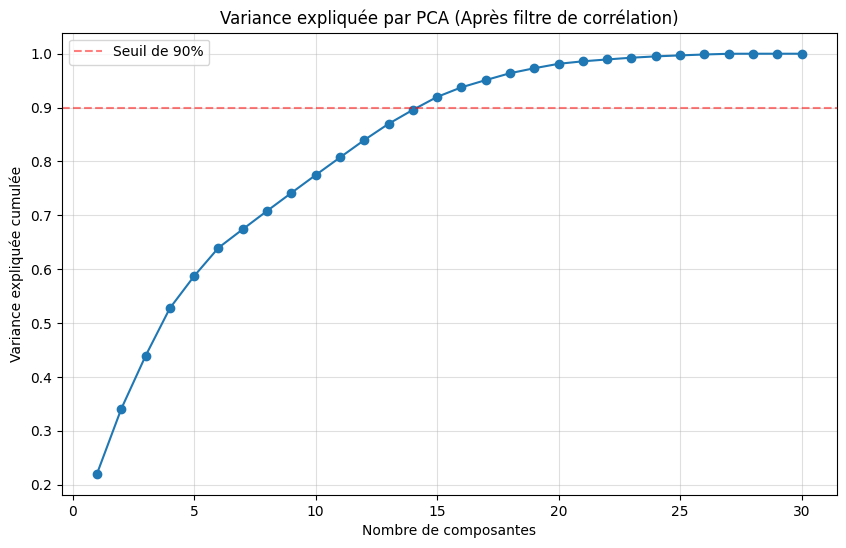

In [9]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# On s'assure qu'on a bien des splits
if len(splits) > 0:
    # 1. Récupération de X_train (en format DataFrame)
    train_idx, val_idx, test_idx, test_year = splits[0]
    X_train_df = df.loc[train_idx, features] 
    
    # ---------------------------------------------------------
    # 2. FILTRE DES CORRÉLATIONS
    # ---------------------------------------------------------
    threshold = 0.8
    col_corr = set()  # Ensemble des colonnes à supprimer
    corr_matrix = X_train_df.corr()

    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)

    print(f"Features à supprimer (corrélation > {threshold}) :")
    print(col_corr)

    # DataFrame réduit
    #df_reduced = X_train_df.drop(columns=col_corr)
    #print(f"Dimensions avant PCA : {df_reduced.shape}")
    
    # ---------------------------------------------------------
    # 3. SCALING & PCA (Sur le DataFrame réduit !)
    # ---------------------------------------------------------
    # Centrage et Réduction
    scaler = StandardScaler()
    X_train_scale = scaler.fit_transform(X_train_df) 
    
    # Entraînement de la PCA
    pca = PCA()
    pca.fit(X_train_scale)

    # Calcul de la variance expliquée
    explained_var = pca.explained_variance_ratio_
    cumulative_var = np.cumsum(explained_var)

    # 4. Affichage du graphique
    plt.figure(figsize=(10, 6))
    # range(1, ...) permet d'avoir l'axe X qui commence à 1 composante (et pas 0)
    plt.plot(range(1, len(cumulative_var) + 1), cumulative_var, marker='o')
    plt.axhline(y=0.90, color='r', linestyle='--', alpha=0.5, label='Seuil de 90%') # Ligne visuelle
    plt.xlabel("Nombre de composantes")
    plt.ylabel("Variance expliquée cumulée")
    plt.title("Variance expliquée par PCA (Après filtre de corrélation)")
    plt.legend()
    plt.grid(True, alpha=0.4)
    plt.show()
    
else:
    print("Pas assez de données pour le split.")

## 3. Evaluation Metrics ($R^2_{OOS}$)

In [10]:
def calculate_r2_oos(y_true, y_pred):
    """
    Out-of-Sample R^2.
    Denominator uses 0 as the prediction benchmark (predicting exactly zero excess return).
    """
    numerator = np.sum((y_true - y_pred)**2)
    denominator = np.sum((y_true - 0)**2)
    return 1 - (numerator / denominator)

### Deep Neural Network (KerasTuner + MLflow Autolog + Ensembling)

In [11]:
def build_model(hp, input_dim):
    """KerasTuner model building function"""
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))
    
    # Tune the number of units in the first Dense layer
    hp_units1 = hp.Int('units_1', min_value=16, max_value=64, step=16)
    model.add(layers.Dense(units=hp_units1, kernel_regularizer=regularizers.l1(1e-5)))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    
    # Tune the number of units in the second Dense layer
    hp_units2 = hp.Int('units_2', min_value=8, max_value=32, step=8)
    model.add(layers.Dense(units=hp_units2, kernel_regularizer=regularizers.l1(1e-5)))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    
    # Third hidden layer (fixed small)
    hp_units3 = hp.Int('units_3', min_value=4, max_value=8, step=2)
    model.add(layers.Dense(units=hp_units3, kernel_regularizer=regularizers.l1(1e-5)))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    
    # Output layer
    model.add(layers.Dense(1))
    
    # Tune the learning rate for the optimizer
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=hp_learning_rate),
                  loss='mse',
                  metrics=['mae'])
    return model

def train_dnn_ensemble(X_train, y_train, X_val, y_val, scaler, num_models=5, epochs=100, patience=5):
    mlflow.tensorflow.autolog(disable=True) 
    
    X_train_scaled = scaler.transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    input_dim = X_train_scaled.shape[1]
    
    # ==========================================
    # 🚀 THE MLOPS FIX: tf.data PIPELINE
    # ==========================================
    batch_size = 32768 # You can increase this to 512 or 1024 if VRAM allows
    
    # 1. Train Dataset: Shuffle, Batch, Cache, and Prefetch
    train_dataset = tf.data.Dataset.from_tensor_slices((X_train_scaled, y_train.values))
    train_dataset = train_dataset.shuffle(buffer_size=len(X_train_scaled)) \
                                 .batch(batch_size) \
                                 .cache() \
                                 .prefetch(tf.data.AUTOTUNE)
                                 
    # 2. Validation Dataset: Batch, Cache, and Prefetch (No need to shuffle val data)
    val_dataset = tf.data.Dataset.from_tensor_slices((X_val_scaled, y_val.values))
    val_dataset = val_dataset.batch(batch_size) \
                             .cache() \
                             .prefetch(tf.data.AUTOTUNE)
    # ==========================================

    print("Starting KerasTuner RandomSearch...")
    with tf.device('/CPU:0'):
        tuner = kt.RandomSearch(
            lambda hp: build_model(hp, input_dim),
            objective='val_loss',
            max_trials=5,     
            directory='keras_tuner_dir',
            project_name='momentum_dnn',
            overwrite=True
        )
    
        early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)
        
        # Pass the datasets instead of raw arrays. Drop the 'batch_size' arg since the dataset handles it.
        tuner.search(train_dataset, epochs=30, validation_data=val_dataset, callbacks=[early_stopping], verbose=0)
        best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
        print(f"Best HPs found: Layer1: {best_hps.get('units_1')}, Layer2: {best_hps.get('units_2')}, LR: {best_hps.get('learning_rate')}")
    
    models = []
    mlflow.tensorflow.autolog() 
    
    for i in range(num_models):
        with mlflow.start_run(run_name=f"DNN_Ensemble_Member_{i+1}", nested=True):
            mlflow.log_params(best_hps.values)
            tf.random.set_seed(42 + i)
            
            model = tuner.hypermodel.build(best_hps)
            
            # Use the pre-built tf.data pipeline for blazing fast training
            history = model.fit(
                train_dataset,
                epochs=epochs,
                validation_data=val_dataset,
                callbacks=[early_stopping],
                verbose=0
            )
            val_loss = min(history.history['val_loss'])
            print(f"Trained DNN component {i+1}/{num_models} - Best Val Loss: {val_loss:.6f}")
            models.append(model)
        
    return models

def predict_dnn_ensemble(models, scaler, X_test):
    X_test_scaled = scaler.transform(X_test)
    
    # Create a fast prediction pipeline
    test_dataset = tf.data.Dataset.from_tensor_slices(X_test_scaled)
    test_dataset = test_dataset.batch(32768).cache().prefetch(tf.data.AUTOTUNE)
    
    preds = []
    for model in models:
        # Pass the dataset to predict
        pred = model.predict(test_dataset, verbose=0).flatten()
        preds.append(pred)
        
    return np.mean(preds, axis=0)


## 5. Backtesting Portfolio Construction (Decile Sorting)

In [12]:
import pandas as pd
import numpy as np

def backtest_portfolio(test_df, predictions_col, transaction_cost=0.001, top_n=10):
    """
    Simulates a Long-Only portfolio with dynamic transaction costs.
    Invests strictly in the Top N performing stocks based on predictions_col.
    """
    results = []
    
    # CRITICAL FIX 1: Sort dataframe before shift(-1)
    test_df = test_df.copy()
    test_df['date'] = pd.to_datetime(test_df['date'])
    test_df = test_df.sort_values(by=['symbol', 'date'])
    
    # Calculate future return (what we will earn if we hold for the next period)
    test_df['return+1'] = test_df.groupby('symbol')['adjClose'].shift(-1) / test_df['adjClose'] - 1
    
    # Initialize empty set to track what we held the previous week
    prev_long_symbols = set()

    for date, week_data in test_df.groupby('date'):
        # Skip weeks with too few stocks to form a proper Top N portfolio
        if len(week_data) < top_n: 
            continue
            
        week_data = week_data.copy()
        
        # --- 1. BENCHMARK CALCULATION ---
        if 'dollar_volume' not in week_data.columns:
            week_data['dollar_volume'] = week_data['volume'] * week_data['adjClose']
            
        universe_weights = week_data['dollar_volume'] / week_data['dollar_volume'].sum()
        benchmark_return = np.sum(universe_weights * week_data['return+1'])
        
        # --- 2. PORTFOLIO TOP N (LONG ONLY) ---
        try:
            # 🚀 NOUVEAU : On trie les actions par la colonne de prédiction/performance
            # ascending=False permet d'avoir les plus grandes valeurs en haut
            week_data = week_data.sort_values(by=predictions_col, ascending=False)
            
            # On prend strictement le Top N
            long_portfolio = week_data.head(top_n)
            
            curr_long_symbols = set(long_portfolio['symbol'])
            num_l = len(curr_long_symbols)
            
            if num_l > 0:
                # Gross Return (Equal-Weighted)
                ret_long = long_portfolio['return+1'].mean()
                gross_portfolio_return = ret_long 
                
                # --- 3. DYNAMIC TRANSACTION COSTS (TURNOVER) ---
                new_longs = curr_long_symbols - prev_long_symbols
                
                # Turnover: Fraction of the portfolio that is new
                turnover_long = len(new_longs) / num_l if prev_long_symbols else 1.0 
                
                # Fee to BUY the new stock AND SELL the old stock
                cost_long = turnover_long * transaction_cost * 2
                
                # Net Return
                net_portfolio_return = gross_portfolio_return - cost_long
                
                # Update memory for the next loop
                prev_long_symbols = curr_long_symbols
            else:
                ret_long, gross_portfolio_return, net_portfolio_return, turnover_long, num_l = 0, 0, 0, 0, 0
                
        except Exception as e:
            ret_long, gross_portfolio_return, net_portfolio_return, turnover_long, num_l = 0, 0, 0, 0, 0
            
        # Append results for this week
        results.append({
            'date': date,
            'gross_return': gross_portfolio_return,
            'portfolio_return': net_portfolio_return,
            'benchmark_return': benchmark_return,
            'turnover_pct': turnover_long,
            'num_long': num_l
        })
            
    bt_df = pd.DataFrame(results)

    # --- METRICS CALCULATION ---
    if bt_df.empty:
        return bt_df, {}
        
    bt_df['date'] = pd.to_datetime(bt_df['date'])
    bt_df = bt_df.dropna(subset=['portfolio_return'])
    
    # Cumulative returns
    bt_df['cum_return'] = (1 + bt_df['portfolio_return']).cumprod()
    bt_df['cum_benchmark'] = (1 + bt_df['benchmark_return']).cumprod()
    bt_df['outperformance'] = bt_df['cum_return'] - bt_df['cum_benchmark']

    n_years = bt_df['date'].dt.year.nunique()
    
    # Portfolio Metrics
    total_ret = bt_df['cum_return'].iloc[-1] - 1
    cagr = (bt_df['cum_return'].iloc[-1]) ** (1 / max(1, n_years)) - 1
    mean_ret = bt_df['portfolio_return'].mean()
    std_ret = bt_df['portfolio_return'].std()
    sharpe = ((mean_ret / std_ret) * np.sqrt(52)) if std_ret > 0 else 0
    max_dd = ((bt_df['cum_return'] - bt_df['cum_return'].cummax()) / bt_df['cum_return'].cummax()).min()

    # Benchmark Metrics
    bench_total_ret = bt_df['cum_benchmark'].iloc[-1] - 1
    bench_cagr = (bt_df['cum_benchmark'].iloc[-1]) ** (1 / max(1, n_years)) - 1 if n_years > 0 and bt_df['cum_benchmark'].iloc[-1] > 0 else 0
    bench_mean = bt_df['benchmark_return'].mean()
    bench_std = bt_df['benchmark_return'].std()
    bench_sharpe = (bench_mean / bench_std) * np.sqrt(52) if bench_std > 0 else 0
    bench_max_dd = ((bt_df['cum_benchmark'] - bt_df['cum_benchmark'].cummax()) / bt_df['cum_benchmark'].cummax()).min()
        
    metrics = {
        'Total_Return': total_ret,
        'CAGR': cagr,
        'Sharpe_Ratio': sharpe,
        'Max_Drawdown': max_dd,
        'Bench_Total_Return': bench_total_ret,
        'Bench_CAGR': bench_cagr,
        'Bench_Sharpe': bench_sharpe,
        'Bench_Max_Drawdown': bench_max_dd
    }
    
    return bt_df, metrics

## 6. Run the Pipeline over the Expanding Window

In [ ]:
if len(splits) > 0:
    print(f"🚀 Lancement du Walk-Forward Backtest sur {len(splits)} années...")
    
    all_oos_results = []

    STRATEGY_FREQ = "weekly"
    TRANS_COST = 0.001
    DNN_EPOCHS = 100
    DNN_MODELS = 5
    TARGET_FREQ = "1 an"
    NUM_SPLITS = 10
    TOP = 10
    NOTES = "Test avec une target de 1 an et une fréquence hebdomadaire avec 1 split. Momentum, Value, Profitable"

    mlflow.set_experiment("Maximize_CAGR_SP500")
    
    run_name = f"Test_{STRATEGY_FREQ}_Cost{TRANS_COST}_DnnEp{DNN_EPOCHS}_DnnModels{DNN_MODELS}_Target{TARGET_FREQ}_Top{TOP}_Splits{NUM_SPLITS}_Notes{NOTES}"

    # On ouvre un seul grand Run MLflow pour tout le backtest
    with mlflow.start_run(run_name="CAGR_Forward_Backtest") as parent_run:

        mlflow.set_tag("Frequency", "Weekly")
        
        # 1. ENREGISTREMENT DES PARAMÈTRES GLOBAUX
        mlflow.log_params({
            "frequency": STRATEGY_FREQ,
            "features_count": len(features),
            "features_list": ", ".join(features),
            "transaction_cost": TRANS_COST,
            "dnn_epochs": DNN_EPOCHS,
            "dnn_num_models": DNN_MODELS,
            "target_freq": TARGET_FREQ,
            "top": TOP,
            "num_splits": NUM_SPLITS,
            "notes": NOTES
        })
        
        # 2. LA BOUCLE SUR TOUTES LES ANNÉES
        for i, (train_idx, val_idx, test_idx, test_year) in enumerate(splits):
            print(f"\n--- Traitement de l'Année de Test {test_year} ({i+1}/{len(splits)}) ---")
            
            X_train, y_train = df.loc[train_idx, features], df.loc[train_idx, 'target_y']
            X_val, y_val = df.loc[val_idx, features], df.loc[val_idx, 'target_y']
            X_test, y_test = df.loc[test_idx, features], df.loc[test_idx, 'target_y']
            
            # Setup scaler for DNN (réajusté chaque année)
            scaler = StandardScaler()
            scaler.fit(X_train)
            
            # Entraînement DNN
            print("  -> Training DNN Ensemble...")
            dnn_models = train_dnn_ensemble(X_train, y_train, X_val, y_val, scaler, num_models=DNN_MODELS, epochs=DNN_EPOCHS, patience=3)
            dnn_preds = predict_dnn_ensemble(dnn_models, scaler, X_test)
            
            # --- SUIVI ANNÉE PAR ANNÉE ---
            r2_dnn_year = float(calculate_r2_oos(y_test.values, dnn_preds))
            
            # On force le cast en int() pour le step !
            mlflow.log_metric("Yearly_DNN_R2_OOS", r2_dnn_year, step=int(test_year))
            
            print(f"  -> DNN R2 {test_year}: {r2_dnn_year:.4f}")
            
            # Stockage des prédictions pour cette année
            test_df_year = df.loc[test_idx].copy()
            test_df_year['dnn_pred'] = dnn_preds
            
            all_oos_results.append(test_df_year)
            
        # =========================================================
        # 3. L'ASSEMBLAGE (Le vrai Backtest Global)
        # =========================================================
        print("\n" + "="*50)
        print("🔗 Assemblage des prédictions et calcul du Backtest Global...")
        
        final_test_df = pd.concat(all_oos_results).sort_values(['symbol', 'date'])
        
        # --- SAUVEGARDE DES PRÉDICTIONS BRUTES EN ARTEFACT ---
        print("💾 Sauvegarde des prédictions brutes dans MLflow...")
        csv_path = "final_predictions.csv"
        final_test_df.to_csv(csv_path, index=False)
        mlflow.log_artifact(csv_path)
        
        # Évaluation R^2 globale sur toute la période OOS
        r2_dnn_global = calculate_r2_oos(final_test_df['target_y'].values, final_test_df['dnn_pred'].values)
        
        mlflow.log_metric("Global_DNN_R2_OOS", r2_dnn_global)
        
        # Passage au simulateur de portefeuille
        print("Running Backtest for DNN Strategy...")
        bt_dnn, metrics_dnn = backtest_portfolio(final_test_df, 'dnn_pred', transaction_cost=TRANS_COST, top_n=TOP)
        
        # 4. AFFICHAGE ET SAUVEGARDE FINALE
        if not bt_dnn.empty:
            
            # Sauvegarde des métriques financières dans MLflow en forçant le type float()
            mlflow.log_metrics({f"DNN_{k}": float(v) for k, v in metrics_dnn.items()})
            
            # Sauvegarde aussi le R2 global en forçant le float() (juste au cas où)
            mlflow.log_metric("Global_DNN_R2_OOS", float(r2_dnn_global))
            
            # Formatage du joli tableau pour la console
            metrics_table = pd.DataFrame({
                "Métrique": ["Total Return", "CAGR (Annualisé)", "Sharpe Ratio", "Max Drawdown"],
                "DNN Ensemble": [f"{metrics_dnn['Total_Return']*100:.2f}%", f"{metrics_dnn['CAGR']*100:.2f}%", f"{metrics_dnn['Sharpe_Ratio']:.2f}", f"{metrics_dnn['Max_Drawdown']*100:.2f}%"]
            })
            
            print("\n" + "="*55)
            print("📊 TABLEAU DES PERFORMANCES FINALES (AVEC FRAIS)")
            print("="*55)
            print(metrics_table.to_string(index=False))
            print("="*55 + "\n")
            
            # Sauvegarde du tableau en format texte brut dans MLflow
            with open("performance_metrics.txt", "w") as f:
                f.write(metrics_table.to_string(index=False))
            mlflow.log_artifact("performance_metrics.txt")
            
        else:
            print("Backtest yielded empty results (perhaps not enough data to form deciles).")
          
else:
    print("Not enough data to form a split. Check your timeframe.")


🚀 Lancement du Walk-Forward Backtest sur 1 années...

--- Traitement de l'Année de Test 2023 (1/1) ---
  -> Training DNN Ensemble...
Starting KerasTuner RandomSearch...


2026-03-13 15:53:53.857740: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2026-03-13 15:53:53.857771: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2026-03-13 15:53:53.857781: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 14.04 GB
I0000 00:00:1773413633.857793  340193 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1773413633.857812  340193 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Best HPs found: Layer1: 48, Layer2: 24, LR: 0.0001


2026-03-13 15:54:06.689222: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-03-13 15:54:06.705457: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


2026-03-13 15:54:07.046982: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


...

Trained DNN component 4/5 - Best Val Loss: 2.791723


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


2026/03/13 15:55:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/13 15:55:07 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during tensorflow autologging: 0.16133590042591095 is not in list


Trained DNN component 5/5 - Best Val Loss: 10.520733


  -> DNN R2 2023: -0.2685

🔗 Assemblage des prédictions et calcul du Backtest Global...
💾 Sauvegarde des prédictions brutes dans MLflow...
Running Backtest for DNN Strategy...

📊 TABLEAU DES PERFORMANCES FINALES (AVEC FRAIS)
        Métrique DNN Ensemble
    Total Return       28.19%
CAGR (Annualisé)        8.63%
    Sharpe Ratio         0.73
    Max Drawdown      -16.85%



## 7. Visualisation results

Running Backtest for DNN Strategy...

📊 TABLEAU DES PERFORMANCES FINALES (HEBDOMADAIRE - AVEC FRAIS 0.1%)
        Métrique DNN Ensemble
    Total Return       53.35%
CAGR (Annualisé)       15.32%
    Sharpe Ratio         0.94
    Max Drawdown      -15.22%



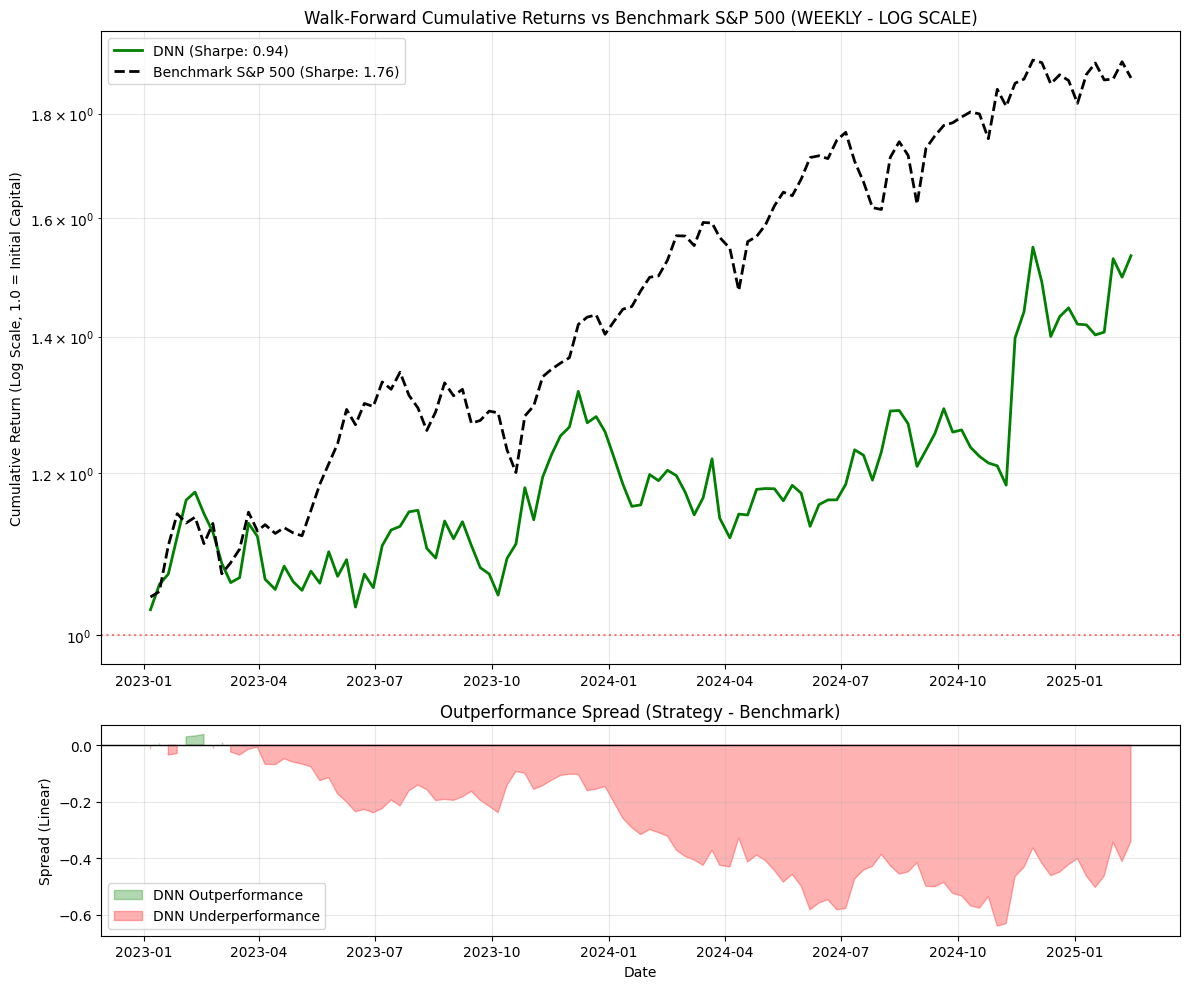

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

print("Running Backtest for DNN Strategy...")
# On garde ton paramétrage (transaction_cost=0.001, decile=55)
bt_dnn, metrics_dnn = backtest_portfolio(final_test_df, 'dnn_pred', transaction_cost=0.001, top_n=5)

if not bt_dnn.empty:
    # 1. TABLEAU DES PERFORMANCES (DNN UNIQUEMENT)
    metrics_table = pd.DataFrame({
        "Métrique": ["Total Return", "CAGR (Annualisé)", "Sharpe Ratio", "Max Drawdown"],
        "DNN Ensemble": [f"{metrics_dnn['Total_Return']*100:.2f}%", f"{metrics_dnn['CAGR']*100:.2f}%", f"{metrics_dnn['Sharpe_Ratio']:.2f}", f"{metrics_dnn['Max_Drawdown']*100:.2f}%"]
    })
    
    print("\n" + "="*55)
    print("📊 TABLEAU DES PERFORMANCES FINALES (HEBDOMADAIRE - AVEC FRAIS 0.1%)")
    print("="*55)
    print(metrics_table.to_string(index=False))
    print("="*55 + "\n")

    # 2. GRAPHIQUES (DNN vs BENCHMARK)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [3, 1]})
    
    # --- Axe 1 : Rendements cumulés (Échelle Logarithmique) ---
    ax1.plot(bt_dnn['date'], bt_dnn['cum_return'], label=f"DNN (Sharpe: {metrics_dnn['Sharpe_Ratio']:.2f})", color='green', linewidth=2)
    
    # On utilise maintenant metrics_dnn pour récupérer le Sharpe du Benchmark
    ax1.plot(bt_dnn['date'], bt_dnn['cum_benchmark'], label=f"Benchmark S&P 500 (Sharpe: {metrics_dnn['Bench_Sharpe']:.2f})", color='black', linestyle='--', linewidth=2)
    
    ax1.axhline(y=1.0, color='red', linestyle=':', alpha=0.5)
    ax1.set_yscale('log')
    ax1.set_title('Walk-Forward Cumulative Returns vs Benchmark S&P 500 (WEEKLY - LOG SCALE)')
    ax1.set_ylabel('Cumulative Return (Log Scale, 1.0 = Initial Capital)')
    ax1.legend()
    ax1.grid(True, which="both", alpha=0.3)
    
    # --- Axe 2 : Spread d'Outperformance (DNN uniquement) ---
    ax2.fill_between(bt_dnn['date'], bt_dnn['outperformance'], 0, where=(bt_dnn['outperformance'] >= 0), color='green', alpha=0.3, label='DNN Outperformance')
    ax2.fill_between(bt_dnn['date'], bt_dnn['outperformance'], 0, where=(bt_dnn['outperformance'] < 0), color='red', alpha=0.3, label='DNN Underperformance')
    
    ax2.axhline(y=0.0, color='black', linewidth=1)
    ax2.set_title('Outperformance Spread (Strategy - Benchmark)')
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Spread (Linear)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()

    # 3. SAUVEGARDE MLFLOW
    plot_path = "global_cumulative_returns_vs_benchmark.png"
    plt.savefig(plot_path)
    mlflow.log_artifact(plot_path)
    
    plt.show()
    
else:
    print("Le backtest du DNN est vide (peut-être pas assez de données pour former les déciles).")

In [15]:
final_test_df.sort_values(by=['date', 'dnn_pred'], ascending=[False, False]).head(20)

,symbol,date,adjClose,volume,market_return,risk_free_rate,retvol,maxret,ill,beta,...,cashConversionCycle,freeCashFlowToEquity,freeCashFlowToFirm,tangibleAssetValue,netCurrentAssetValue,year,month,week,target_y,dnn_pred
630598,WST,2025-02-21,210.17,1882059,-0.017064,0.000171,0.801905,0.805714,0.268571,-0.996190,...,92.572921,2.675000e+08,1.107410e+08,2.565400e+09,5.770000e+08,2025,2,4,0.147262,0.342642
193583,EA,2025-02-21,130.32,4866600,-0.017064,0.000171,-0.638095,-0.508571,-0.695238,-0.760000,...,19.477842,1.953000e+09,3.458519e+08,1.716000e+09,-1.767000e+09,2025,2,4,0.537753,0.320104
86239,BIIB,2025-02-21,140.64,1814000,-0.017064,0.000171,-0.036190,0.603810,-0.081905,-0.950476,...,382.600615,-3.560700e+09,5.970631e+07,5.459000e+08,-3.876500e+09,2025,2,4,0.365401,0.277473
498023,PYPL,2025-02-21,74.78,15171700,-0.017064,0.000171,0.314286,-0.428571,-0.672381,0.588571,...,-319.635260,-1.127000e+09,9.331184e+08,9.254000e+09,-1.020000e+08,2025,2,4,-0.443033,0.269654
307688,ILMN,2025-02-21,94.20,4226504,-0.017064,0.000171,0.824762,0.356190,0.432381,0.725714,...,139.254741,-1.160000e+09,4.518723e+08,9.650000e+08,-1.184000e+09,2025,2,4,0.249151,0.269122
503246,REGN,2025-02-21,696.53,727437,-0.017064,0.000171,-0.862857,0.188571,-0.470476,-0.516190,...,513.305573,7.796000e+08,1.743157e+09,2.820500e+10,1.025510e+10,2025,2,4,0.119363,0.243077
336081,KDP,2025-02-21,33.01,17595206,-0.017064,0.000171,-0.504762,0.660952,0.123810,-0.790476,...,-46.528376,-1.608000e+10,5.979610e+08,-1.944400e+10,-2.519000e+10,2025,2,4,-0.105120,0.241552
83999,BG,2025-02-21,70.87,2081421,-0.017064,0.000171,-0.287619,0.592381,0.649524,-0.931429,...,45.014568,-3.244000e+09,6.652055e+07,1.017500e+10,2.008000e+09,2025,2,4,0.720756,0.240581
406955,MRNA,2025-02-21,35.53,21449000,-0.017064,0.000171,0.969524,0.969524,0.653333,-0.763810,...,20.657793,1.483000e+09,-4.324324e+06,1.080900e+10,4.858000e+09,2025,2,4,0.403603,0.234517
203876,EL,2025-02-21,70.56,3565600,-0.017064,0.000171,0.702857,0.908571,0.329524,-0.112381,...,117.935427,-5.872000e+09,-5.693077e+08,-2.062000e+09,-8.695000e+09,2025,2,4,0.618906,0.234002


In [16]:
final_test_df[final_test_df['date'] == '2023-01-06'].sort_values(by='dnn_pred', ascending=False).head(10)

,symbol,date,adjClose,volume,market_return,risk_free_rate,retvol,maxret,ill,beta,...,cashConversionCycle,freeCashFlowToEquity,freeCashFlowToFirm,tangibleAssetValue,netCurrentAssetValue,year,month,week,target_y,dnn_pred
292850,HPQ,2023-01-06,25.34,5501700,0.022841,0.000185,0.110680,0.681553,0.141748,0.467961,...,-15.364735,-7.389000e+09,2.702614e+09,-1.349900e+10,-2.178300e+10,2023,1,4,0.094712,0.585226
618930,WELL,2023-01-06,65.00,1685007,0.022841,0.000185,0.401942,0.421359,0.627184,0.514563,...,119.582675,-1.408861e+10,-7.413121e+08,2.132568e+10,-1.342309e+10,2023,1,4,0.307538,0.569178
556835,T,2023-01-06,16.31,36050329,0.022841,0.000185,-0.922330,-0.518447,-0.766990,-0.755340,...,-105.687594,-1.448940e+11,-1.801445e+10,-9.088400e+10,-2.632880e+11,2023,1,4,-0.045984,0.393361
261543,GNRC,2023-01-06,100.75,1394548,0.022841,0.000185,0.879612,0.693204,0.631068,0.860194,...,167.098337,-1.387762e+09,1.262823e+08,3.813200e+07,-6.173880e+08,2023,1,4,0.167444,0.391423
611509,VZ,2023-01-06,33.90,26010400,0.022841,0.000185,-0.972816,-0.316505,-0.813592,-0.906796,...,33.909078,-1.728230e+11,2.636006e+09,-9.746500e+10,-2.493600e+11,2023,1,4,0.022714,0.377453
98997,BXP,2023-01-06,56.40,1458913,0.022841,0.000185,0.774757,0.720388,0.766990,0.899029,...,26.576897,-1.377938e+10,4.370120e+08,8.363819e+09,-1.361409e+10,2023,1,4,0.121631,0.361915
166190,D,2023-01-06,53.23,7520076,0.022841,0.000185,0.203883,-0.153398,-0.440777,-0.568932,...,58.774616,-4.242300e+10,-1.232009e+09,2.270300e+10,-6.728600e+10,2023,1,4,-0.163442,0.355891
93360,BMY,2023-01-06,63.66,7311144,0.022841,0.000185,-0.941748,-0.782524,-0.891262,-0.654369,...,97.137463,-2.863400e+10,7.003253e+09,-2.638600e+10,-3.842900e+10,2023,1,4,-0.256048,0.342409
303192,IBM,2023-01-06,128.06,3574042,0.022841,0.000185,-0.724272,-0.650485,-0.759223,-0.343689,...,5.905885,-4.257100e+10,4.787040e+09,-4.511200e+10,-7.610400e+10,2023,1,4,0.162658,0.333950
214827,ESS,2023-01-06,191.37,611800,0.022841,0.000185,0.825243,0.689320,0.743689,0.914563,...,-241.247597,-5.882759e+09,2.922766e+08,5.922266e+09,-6.192170e+09,2023,1,4,0.182787,0.333762


In [17]:
final_test_df[final_test_df['date'] == '2023-01-06'].sort_values(by='target_y', ascending=False).head(10)

,symbol,date,adjClose,volume,market_return,risk_free_rate,retvol,maxret,ill,beta,...,cashConversionCycle,freeCashFlowToEquity,freeCashFlowToFirm,tangibleAssetValue,netCurrentAssetValue,year,month,week,target_y,dnn_pred
444448,NVDA,2023-01-06,14.84,405044000,0.022841,0.000185,0.817476,0.654369,-0.980583,0.910680,...,171.306545,-9.086000e+09,4.105104e+09,1.512700e+10,4.084000e+09,2023,1,4,2.306604,0.080404
392880,META,2023-01-06,129.12,27584500,0.022841,0.000185,-0.324272,0.483495,-0.976699,-0.623301,...,-16.195917,-6.442000e+09,1.280177e+09,1.045100e+11,-4.650000e+08,2023,1,4,1.706784,0.075865
502101,RCL,2023-01-06,54.04,3117928,0.022841,0.000185,0.895146,0.972816,0.456311,0.196117,...,-3.005748,-2.164920e+10,-1.463746e+09,2.060000e+09,-2.770200e+10,2023,1,4,1.230385,0.277134
37358,AMD,2023-01-06,63.96,70161340,0.022841,0.000185,0.522330,-0.234951,-0.968932,0.755340,...,102.343442,2.415000e+09,2.184737e+08,6.455000e+09,2.189000e+09,2023,1,4,1.166667,-0.012735
481532,PHM,2023-01-06,47.18,1952734,0.022841,0.000185,-0.883495,-0.231068,0.401942,-0.786408,...,280.139832,-7.695360e+08,-8.827305e+08,8.778293e+09,7.500014e+09,2023,1,4,1.119330,0.118068
579354,TSLA,2023-01-06,113.06,220911100,0.022841,0.000185,0.992233,0.817476,-0.992233,0.992233,...,-0.802282,1.192500e+10,3.971328e+07,4.530500e+10,4.477000e+09,2023,1,4,1.100566,0.333301
44323,ANET,2023-01-06,28.11,9314232,0.022841,0.000185,0.848544,-0.130097,-0.118447,0.440777,...,252.808432,6.577560e+08,-6.117004e+07,4.497691e+09,3.661158e+09,2023,1,4,1.053718,0.115260
381749,MBC,2023-01-06,7.55,3381260,0.022841,0.000185,0.693204,-0.366990,0.972816,0.697087,...,57.283172,-8.148000e+08,1.580000e+08,-2.648000e+08,-6.902000e+08,2023,1,4,0.884768,0.031817
113643,CCL,2023-01-06,9.16,40099578,0.022841,0.000185,0.933981,0.984466,0.064078,-0.099029,...,-6.013992,-3.315000e+10,-3.173839e+09,5.329000e+09,-3.714700e+10,2023,1,4,0.883188,0.225704
435528,NOW,2023-01-06,73.31,13383640,0.022841,0.000185,0.883495,-0.499029,-0.549515,0.766990,...,20.604086,2.560000e+08,5.047377e+08,3.976000e+09,-1.613000e+09,2023,1,4,0.844632,0.056120


In [18]:
df_test_decile = final_test_df.copy()

In [19]:
df_test_decile['decile'] = pd.qcut(df_test_decile['dnn_pred'], 65, labels=False, duplicates='drop') + 1
df_test_decile.describe()


,date,adjClose,volume,market_return,risk_free_rate,retvol,maxret,ill,beta,mom1w,...,freeCashFlowToEquity,freeCashFlowToFirm,tangibleAssetValue,netCurrentAssetValue,year,month,week,target_y,dnn_pred,decile
count,55765,55765.000000,5.576500e+04,55765.000000,55765.000000,55765.000000,55765.000000,55765.000000,55765.000000,55765.000000,...,5.576500e+04,5.576500e+04,5.576500e+04,5.576500e+04,55765.000000,55765.000000,55765.000000,55765.000000,55765.000000,55765.000000
mean,2024-01-29 20:16:16.354343936,179.153233,6.077840e+06,0.001430,0.000205,-0.009903,-0.006754,-0.018105,-0.002061,0.001336,...,-1.337291e+10,3.631769e+08,7.828948e+09,-4.615995e+10,2023.607550,6.185582,3.982175,0.144992,0.042032,33.000000
min,2023-01-06 00:00:00,2.560000,6.712000e+03,-0.018385,0.000171,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-4.967580e+11,-1.184472e+12,-9.746500e+10,-2.878834e+12,2023.000000,1.000000,3.000000,-0.842386,-0.504850,1.000000
25%,2023-07-21 00:00:00,54.990000,1.026300e+06,-0.002831,0.000188,-0.506744,-0.502913,-0.510680,-0.499029,-0.495220,...,-1.373174e+10,5.964350e+07,-2.544000e+09,-2.700752e+10,2023.000000,3.000000,4.000000,-0.061289,-0.019122,17.000000
50%,2024-02-02 00:00:00,102.790000,2.119905e+06,0.001165,0.000215,-0.013384,-0.009524,-0.024762,-0.001942,0.001927,...,-5.038300e+09,3.386068e+08,1.671000e+09,-8.501640e+09,2024.000000,6.000000,4.000000,0.117631,0.041950,33.000000
75%,2024-08-09 00:00:00,196.680000,4.883351e+06,0.006718,0.000217,0.483495,0.487572,0.471845,0.495146,0.498084,...,-1.381500e+09,9.972131e+08,9.423976e+09,-2.399332e+09,2024.000000,9.000000,4.000000,0.304404,0.100121,49.000000
max,2025-02-21 00:00:00,9924.400000,1.142269e+09,0.022841,0.000223,1.000000,1.000000,1.000000,1.000000,1.000000,...,2.329720e+11,3.321891e+11,5.320010e+11,5.567500e+10,2025.000000,12.000000,4.000000,4.823990,12.240621,65.000000
std,NaN,405.534367,2.312658e+07,0.008368,0.000017,0.573399,0.574592,0.570741,0.574618,0.574878,...,3.570956e+10,2.885424e+10,3.893314e+10,1.924355e+11,0.616905,3.572711,0.132315,0.321214,0.208274,18.762094


In [20]:
max_decile = df_test_decile['decile'].max()
decile_long = df_test_decile[df_test_decile['decile'] == max_decile].sort_values(by='date', ascending=True)
decile_long_error = decile_long[decile_long['target_y'] < 0]
percent_false = len(decile_long_error)/len(decile_long)
percent_false

0.34382284382284384

In [21]:
min_decile = df_test_decile['decile'].min()
decile_short = df_test_decile[df_test_decile['decile'] == min_decile].sort_values(by='date', ascending=True)
decile_short_error = decile_short[decile_short['target_y'] > 0]
percent_false = len(decile_short_error)/len(decile_short)
percent_false

0.5909090909090909

In [22]:
decile_long.sort_values(by='date', ascending=False).head(20)

,symbol,date,adjClose,volume,market_return,risk_free_rate,retvol,maxret,ill,beta,...,freeCashFlowToEquity,freeCashFlowToFirm,tangibleAssetValue,netCurrentAssetValue,year,month,week,target_y,dnn_pred,decile
307688,ILMN,2025-02-21,94.20,4226504,-0.017064,0.000171,0.824762,0.356190,0.432381,0.725714,...,-1.160000e+09,4.518723e+08,9.650000e+08,-1.184000e+09,2025,2,4,0.249151,0.269122,65
86239,BIIB,2025-02-21,140.64,1814000,-0.017064,0.000171,-0.036190,0.603810,-0.081905,-0.950476,...,-3.560700e+09,5.970631e+07,5.459000e+08,-3.876500e+09,2025,2,4,0.365401,0.277473,65
498023,PYPL,2025-02-21,74.78,15171700,-0.017064,0.000171,0.314286,-0.428571,-0.672381,0.588571,...,-1.127000e+09,9.331184e+08,9.254000e+09,-1.020000e+08,2025,2,4,-0.443033,0.269654,65
193583,EA,2025-02-21,130.32,4866600,-0.017064,0.000171,-0.638095,-0.508571,-0.695238,-0.760000,...,1.953000e+09,3.458519e+08,1.716000e+09,-1.767000e+09,2025,2,4,0.537753,0.320104,65
630598,WST,2025-02-21,210.17,1882059,-0.017064,0.000171,0.801905,0.805714,0.268571,-0.996190,...,2.675000e+08,1.107410e+08,2.565400e+09,5.770000e+08,2025,2,4,0.147262,0.342642,65
5364,ABBV,2025-02-14,186.60,3976903,-0.000075,0.000172,-0.946667,-0.721905,-0.912381,-0.645714,...,-5.556000e+10,-3.148841e+08,-9.166000e+10,-1.062150e+11,2025,2,4,0.240622,0.405715,65
630597,WST,2025-02-14,213.98,5027338,-0.000075,0.000172,1.000000,0.961905,0.733333,-1.000000,...,2.675000e+08,1.107410e+08,2.565400e+09,5.770000e+08,2025,2,4,0.170623,0.292673,65
22417,AES,2025-02-14,9.39,18458200,-0.000075,0.000172,0.702857,0.036190,0.779048,0.836190,...,-2.797600e+10,-7.369805e+08,5.412000e+09,-3.287100e+10,2025,2,4,0.733759,0.264087,65
203875,EL,2025-02-14,67.50,3722116,-0.000075,0.000172,0.862857,0.900952,0.569524,0.866667,...,-5.872000e+09,-5.693077e+08,-2.062000e+09,-8.695000e+09,2025,2,4,0.603556,0.304355,65
212792,ERIE,2025-02-14,382.42,82500,-0.000075,0.000172,0.760000,0.680000,0.969524,0.923810,...,4.141400e+08,-2.012486e+07,1.987258e+09,2.436760e+08,2025,2,4,-0.270148,0.260404,65
